Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
사용 중인 디바이스: cuda
모델 로드 완료.


<ipython-input-2-8382cc4f83f7>:160: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_save_path))


데이터 로드 완료, 초기 열: Index(['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports'],
      dtype='object')

### 결측값 상태 ###
id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinp

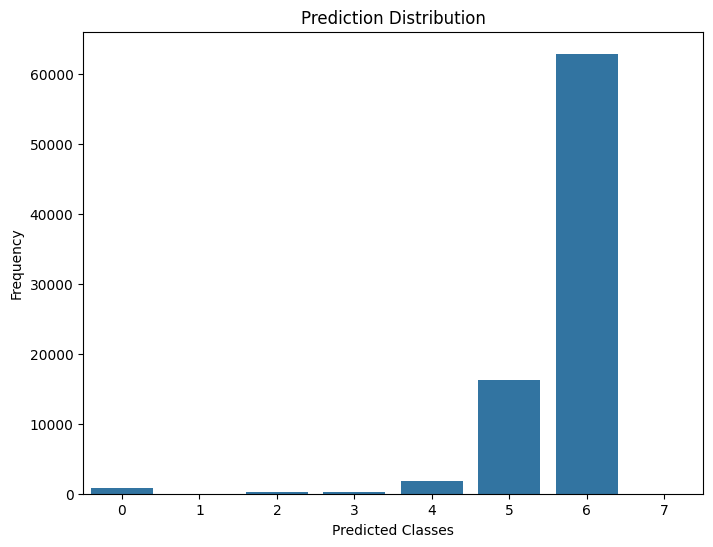

attack_cat 예측 값 샘플: ['Normal' 'DoS' 'Normal' 'Normal' 'Normal']
최종 예측 결과가 /content/drive/My Drive/result/submission.csv에 저장되었습니다.


<ipython-input-2-8382cc4f83f7>:195: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  submission_df['attack_cat'].fillna('Unknown', inplace=True)


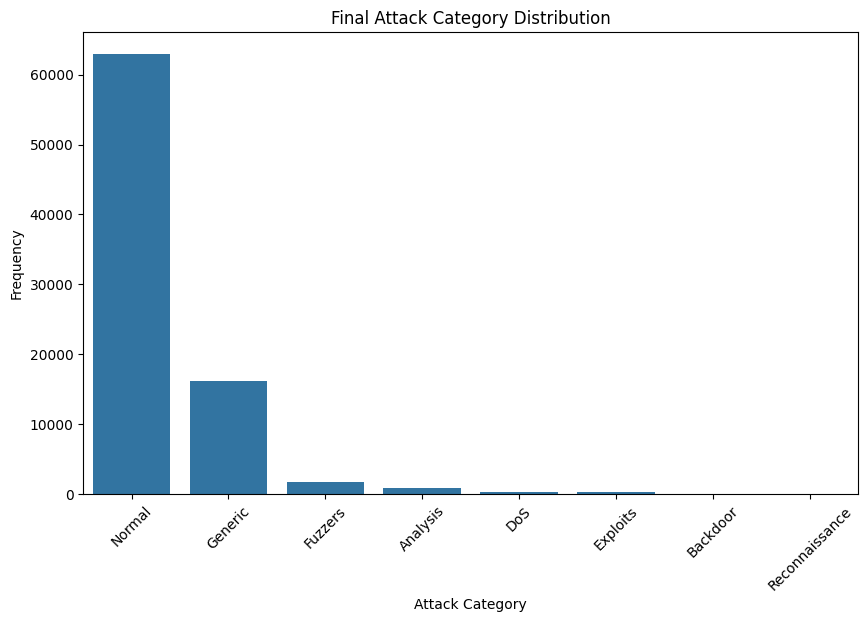

In [2]:
#Test_code 2021245151 정용의

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

drive.mount('/content/drive')

test_path = '/content/drive/My Drive/실습/test-set.csv'
scaler_save_path = '/content/drive/My Drive/result/scaler.pkl'
model_save_path = '/content/drive/My Drive/result/train_model.pth'
columns_save_path = '/content/drive/My Drive/result/columns.pkl'
submission_save_path = '/content/drive/My Drive/result/submission.csv'
label_encoder_path = '/content/drive/My Drive/result/label_encoder.pkl'

def Load_data(file_path, scaler_path, columns_path):

    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip().str.lower()
        print("데이터 로드 완료, 초기 열:", df.columns)
    except FileNotFoundError:
        print(f"파일이 존재하지 않습니다: {file_path}")
        return None, None, None
    except Exception as e:
        print(f"데이터 로드 중 오류가 발생했습니다: {e}")
        return None, None, None

    try:
        print("\n### 결측값 상태 ###")
        print(df.isnull().sum())
        null_mask = df.isnull().any(axis=1)
        ids_full = df['id'].values if 'id' in df.columns else np.arange(len(df))
        ids = df['id'].values[~null_mask] if 'id' in df.columns else np.arange(len(df))
        df.dropna(inplace=True)
        print(f"\n결측값 처리 후 데이터 크기: {df.shape}")

        if 'id' in df.columns:
            df.drop(columns=['id'], inplace=True)
    except Exception as e:
        print(f"결측값 처리 중 오류가 발생했습니다: {e}")
        return None, None, None

    try:
        categorical_columns = ['proto', 'service', 'state']
        df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
        print("범주형 변수 원-핫 인코딩 완료.")
    except KeyError as e:
        print(f"범주형 변수 컬럼이 누락되었습니다: {e}")
        return None, None, None
    except Exception as e:
        print(f"원-핫 인코딩 중 오류가 발생했습니다: {e}")
        return None, None, None

    try:
        binary_columns = ['is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports']
        for col in binary_columns:
            df[col] = df[col].apply(lambda x: 1 if x == '1' else 0)
        print("이진 변수 처리 완료.")
    except KeyError as e:
        print(f"이진 변수 컬럼이 누락되었습니다: {e}")
        return None, None, None
    except Exception as e:
        print(f"이진 변수 처리 중 오류가 발생했습니다: {e}")
        return None, None, None

    try:
        if not os.path.exists(columns_path):
            print(f"컬럼 파일이 존재하지 않습니다: {columns_path}")
            return None, None, None
        expected_columns = joblib.load(columns_path)
        df = df.reindex(columns=expected_columns, fill_value=0)
        print("컬럼 순서 정렬 완료.")
    except Exception as e:
        print(f"컬럼 정렬 중 오류가 발생했습니다: {e}")
        return None, None, None

    try:
        if not os.path.exists(scaler_path):
            print(f"스케일러 파일이 존재하지 않습니다: {scaler_path}")
            return None, None, None
        scaler = joblib.load(scaler_path)
        features = scaler.transform(df.values)
        print("스케일러 적용 완료.")
    except Exception as e:
        print(f"스케일링 중 오류가 발생했습니다: {e}")
        return None, None, None

    return features, ids, ids_full

class AttentionGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=1):
        super(AttentionGRU, self).__init__()
        try:
            self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
            self.attn = nn.Linear(hidden_dim, 1)
            self.fc = nn.Linear(hidden_dim, num_classes)
        except Exception as e:
            print(f"모델 초기화 중 오류가 발생했습니다: {e}")

    def forward(self, x):
        try:
            x, _ = self.gru(x)
            attn_weights = torch.softmax(self.attn(x), dim=1)
            x = torch.sum(attn_weights * x, dim=1)
            return self.fc(x)
        except RuntimeError as e:
            print(f"모델 순전파 중 오류가 발생했습니다: {e}")
            return

def evaluate_and_predict(model, X_test, device):
    try:
        test_loader = DataLoader(TensorDataset(torch.tensor(X_test, dtype=torch.float32).unsqueeze(1)), batch_size=256)
        all_preds = []
        model.eval()
        with torch.no_grad():
            for inputs in test_loader:
                inputs = inputs[0].to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                all_preds.extend(predicted.cpu().numpy())
        print("예측된 클래스 샘플:", all_preds[:20])

        plt.figure(figsize=(8, 6))
        sns.countplot(x=all_preds)
        plt.xlabel("Predicted Classes")
        plt.ylabel("Frequency")
        plt.title("Prediction Distribution")
        plt.show()
    except Exception as e:
        print(f"평가 및 예측 중 오류가 발생했습니다: {e}")
        return None
    return all_preds

def attack_cat_mapping(preds, label_encoder):
    try:
        return label_encoder.inverse_transform(preds)
    except RuntimeError as e:
        print(f"레이블 디코딩 중 오류가 발생했습니다: {e}")
        return

def main():
    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"사용 중인 디바이스: {device}")
    except RuntimeError as e:
        print(f"디바이스 설정 중 오류가 발생했습니다: {e}")
        return

    try:
        model = AttentionGRU(input_dim=56, hidden_dim=128, num_classes=9, num_layers=1)
        model.load_state_dict(torch.load(model_save_path))
        model.to(device)
        print("모델 로드 완료.")
    except FileNotFoundError:
        print(f"{model_save_path} 파일이 존재하지 않습니다. 경로를 확인하세요.")
        return
    except RuntimeError as e:
        print(f"모델 로드 중 오류가 발생했습니다: {e}")
        return

    X_test, ids, ids_full = Load_data(test_path, scaler_save_path, columns_save_path)
    if X_test is None:
        print("테스트 데이터 로드 실패로 인해 프로세스를 종료합니다.")
        return

    predicted_labels = evaluate_and_predict(model, X_test, device)
    if predicted_labels is None:
        print("예측 과정에서 오류가 발생했습니다.")
        return

    try:
        label_encoder = joblib.load(label_encoder_path)
        predicted_attack_cat = attack_cat_mapping(predicted_labels, label_encoder)
        print("attack_cat 예측 값 샘플:", predicted_attack_cat[:5])
    except FileNotFoundError:
        print(f"{label_encoder_path} 파일이 존재하지 않습니다.")
        return
    except RuntimeError as e:
        print(f"레이블 디코더 로드 중 오류가 발생했습니다: {e}")
        return

    try:
        prediction_df = pd.DataFrame({'id': ids, 'attack_cat': predicted_attack_cat})
        full_df = pd.DataFrame({'id': ids_full})
        submission_df = full_df.merge(prediction_df, on='id', how='left')
        submission_df['attack_cat'].fillna('Unknown', inplace=True)
        submission_df.to_csv(submission_save_path, index=False)
        print(f"최종 예측 결과가 {submission_save_path}에 저장되었습니다.")

        plt.figure(figsize=(10, 6))
        sns.countplot(data=submission_df, x='attack_cat', order=submission_df['attack_cat'].value_counts().index)
        plt.xlabel("Attack Category")
        plt.ylabel("Frequency")
        plt.title("Final Attack Category Distribution")
        plt.xticks(rotation=45)
        plt.show()
    except Exception as e:
        print(f"결과 저장 또는 시각화 중 오류가 발생했습니다: {e}")
        return

if __name__ == "__main__":
    main()